# Trainset

In [ ]:
import cv2
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt  # <-- thêm dòng này

IMAGE_TO_VISUALIZE = '0012.png'

GT_PATH = "/home/hp/VTAIRACE/source_lam/dataset/Train/Public_train.csv"
PRED_PATH = "/home/hp/VTAIRACE/source_lam/ps6d/Submission3D_train.csv"
IMAGE_DIR = "/home/hp/VTAIRACE/source_lam/dataset/Train/rgb"

color_intrinsics = {
    'width': 1280, 'height': 720,
    'fx': 643.90087890625, 'fy': 643.1365356445312,
    'cx': 650.2113037109375, 'cy': 355.79559326171875,
}

def project_3d_to_2d(p3d, intr):
    """Chiếu điểm 3D sang 2D pixel."""
    x, y, z = p3d[0], p3d[1], p3d[2]
    if z < 1e-5:
        return None
    u = (x * intr['fx'] / z) + intr['cx']
    v = (y * intr['fy'] / z) + intr['cy']
    return np.array([u, v])

def main_visualize():
    print(f"Bắt đầu visualize cho ảnh: {IMAGE_TO_VISUALIZE}")

    img_path = os.path.join(IMAGE_DIR, IMAGE_TO_VISUALIZE)
    if not os.path.exists(img_path):
        print(f"LỖI: Không tìm thấy ảnh tại {img_path}")
        return
    image = cv2.imread(img_path)
    if image is None:
        print(f"LỖI: cv2 không thể đọc ảnh {img_path}")
        return

    try:
        gt_df = pd.read_csv(GT_PATH)
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file GT tại {GT_PATH}")
        return

    try:
        pred_df = pd.read_csv(PRED_PATH)
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file dự đoán tại {PRED_PATH}")
        print("Vui lòng chạy file integrated_pipeline.py trước.")
        return

    gt_2d = pred_2d = gt_3d = pred_3d = None

    # --- Lấy GT ---
    try:
        gt_image_name = f"image_{IMAGE_TO_VISUALIZE}"
        gt_row = gt_df[gt_df['image_filename'] == gt_image_name].iloc[0]
        gt_3d = np.array([gt_row['x'], gt_row['y'], gt_row['z']])
        gt_2d = project_3d_to_2d(gt_3d, color_intrinsics)
    except Exception as e:
        print(f"Warning: Không tìm thấy GT cho {IMAGE_TO_VISUALIZE}. Lỗi: {e}")

    # --- Lấy PRED ---
    try:
        pred_row = pred_df[pred_df['image_filename'] == IMAGE_TO_VISUALIZE].iloc[0]
        if pd.isna(pred_row['x']):
            print(f"Warning: Dự đoán cho {IMAGE_TO_VISUALIZE} bị thiếu (NaN).")
        else:
            pred_3d = np.array([pred_row['x'], pred_row['y'], pred_row['z']])
            pred_2d = project_3d_to_2d(pred_3d, color_intrinsics)
    except Exception as e:
        print(f"Warning: Không tìm thấy dự đoán cho {IMAGE_TO_VISUALIZE}. Lỗi: {e}")

    # --- Tính khoảng cách ---
    dist_cam_to_gt = np.linalg.norm(gt_3d) if gt_3d is not None else None
    dist_cam_to_pred = np.linalg.norm(pred_3d) if pred_3d is not None else None

    # --- Vẽ ---
    if gt_2d is not None:
        gt_pix = (int(round(gt_2d[0])), int(round(gt_2d[1])))
        cv2.circle(image, gt_pix, 5, (0, 255, 0), 2)
        cv2.putText(image, "GT", (gt_pix[0] + 10, gt_pix[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        print(f"  -> GT (Xanh): {gt_3d} -> {gt_pix}")

    if pred_2d is not None:
        pred_pix = (int(round(pred_2d[0])), int(round(pred_2d[1])))
        cv2.circle(image, pred_pix, 5, (0, 0, 255), 2)
        cv2.putText(image, "PRED", (pred_pix[0] + 10, pred_pix[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        print(f"  -> PRED (Đỏ): {pred_3d} -> {pred_pix}")

    # --- Hiển thị kết quả bằng Matplotlib ---
    print("\n✅ Hiển thị kết quả (GT=Xanh, PRED=Đỏ):")
    if dist_cam_to_gt is not None:
        print(f"  -> Khoảng cách 3D (Camera -> GT):   {dist_cam_to_gt * 1000:.2f} mm")
    if dist_cam_to_pred is not None:
        print(f"  -> Khoảng cách 3D (Camera -> PRED): {dist_cam_to_pred * 1000:.2f} mm")

    # Chuyển ảnh BGR -> RGB để matplotlib hiển thị đúng màu
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.title(f"Visualization: {IMAGE_TO_VISUALIZE}")
    plt.axis('off')
    plt.show()

# --- Chạy ---
main_visualize()


# Testset

Bắt đầu visualize cho ảnh: 0353.png
  -> PRED (Đỏ): [-9.31000e-04  8.91290e-02  1.08063e+00] -> (650, 409)


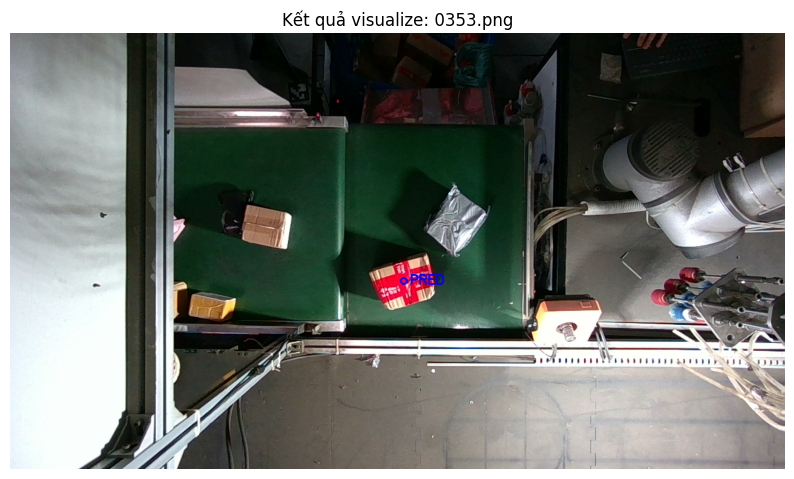

In [22]:
import cv2
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt  # 👈 Thay thế cv2_imshow

# --- Đường dẫn ---
IMAGE_TO_VISUALIZE = '0353.png'
PRED_PATH = "/home/hp/VTAIRACE/source_lam/ps6d/Submission_3D.csv"
IMAGE_DIR = "/home/hp/VTAIRACE/source_lam/dataset/Test/rgb"

# --- Thông số camera ---
color_intrinsics = {
    'width': 1280, 'height': 720,
    'fx': 643.90087890625, 'fy': 643.1365356445312,
    'cx': 650.2113037109375, 'cy': 355.79559326171875,
}

# --- Hàm chiếu 3D -> 2D ---
def project_3d_to_2d(p3d, intr):
    x, y, z = p3d[0], p3d[1], p3d[2]
    if z < 1e-5:
        return None
    u = (x * intr['fx'] / z) + intr['cx']
    v = (y * intr['fy'] / z) + intr['cy']
    return np.array([u, v])

# --- Hàm visualize ---
def main_visualize_simple():
    print(f"Bắt đầu visualize cho ảnh: {IMAGE_TO_VISUALIZE}")

    # 1. Load ảnh RGB
    img_path = os.path.join(IMAGE_DIR, IMAGE_TO_VISUALIZE)
    if not os.path.exists(img_path):
        print(f"LỖI: Không tìm thấy ảnh tại {img_path}")
        return
    image = cv2.imread(img_path)
    if image is None:
        print(f"LỖI: cv2 không thể đọc ảnh {img_path}")
        return

    # 2. Load file submission
    try:
        pred_df = pd.read_csv(PRED_PATH)
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file dự đoán tại {PRED_PATH}")
        return

    pred_2d = None
    pred_3d = None

    # 3. Lấy tọa độ dự đoán
    try:
        pred_row = pred_df[pred_df['image_filename'].str.endswith(IMAGE_TO_VISUALIZE)].iloc[0]

        if pd.isna(pred_row['x']):
            print(f"Warning: Dự đoán cho {IMAGE_TO_VISUALIZE} bị thiếu (NaN).")
        else:
            pred_3d = np.array([pred_row['x'], pred_row['y'], pred_row['z']])
            pred_2d = project_3d_to_2d(pred_3d, color_intrinsics)
    except Exception as e:
        print(f"Warning: Không tìm thấy dự đoán cho {IMAGE_TO_VISUALIZE}. Lỗi: {e}")

    # 4. Vẽ điểm dự đoán
    if pred_2d is not None:
        pred_pix = (int(round(pred_2d[0])), int(round(pred_2d[1])))
        cv2.circle(image, pred_pix, 5, (255, 0, 0), 2)
        cv2.putText(image, "PRED", (pred_pix[0] + 10, pred_pix[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        print(f"  -> PRED (Đỏ): {pred_3d} -> {pred_pix}")
    else:
        print(f"Không có tọa độ dự đoán hợp lệ để vẽ cho ảnh {IMAGE_TO_VISUALIZE}.")

    # 5. Hiển thị (dùng matplotlib thay cv2_imshow)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(f"Kết quả visualize: {IMAGE_TO_VISUALIZE}")
    plt.show()

# --- Chạy ---
main_visualize_simple()


Bắt đầu visualize cho ảnh: 0353.png
  -> PRED (Đỏ): [-0.     0.087  1.079] -> (650, 408)


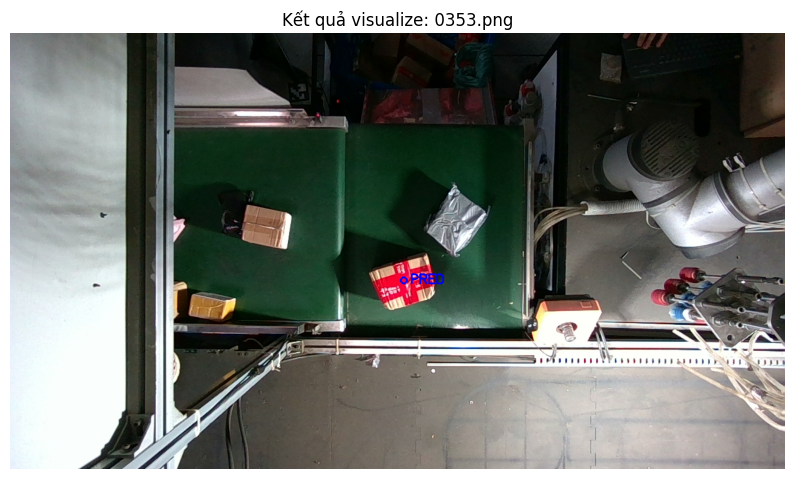

In [23]:
import cv2
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt  # 👈 Thay thế cv2_imshow

# --- Đường dẫn ---
IMAGE_TO_VISUALIZE = '0353.png'
PRED_PATH = "/home/hp/VTAIRACE/source_lam/ps6d/Submission_3D1.csv"
IMAGE_DIR = "/home/hp/VTAIRACE/source_lam/dataset/Test/rgb"

# --- Thông số camera ---
color_intrinsics = {
    'width': 1280, 'height': 720,
    'fx': 643.90087890625, 'fy': 643.1365356445312,
    'cx': 650.2113037109375, 'cy': 355.79559326171875,
}

# --- Hàm chiếu 3D -> 2D ---
def project_3d_to_2d(p3d, intr):
    x, y, z = p3d[0], p3d[1], p3d[2]
    if z < 1e-5:
        return None
    u = (x * intr['fx'] / z) + intr['cx']
    v = (y * intr['fy'] / z) + intr['cy']
    return np.array([u, v])

# --- Hàm visualize ---
def main_visualize_simple():
    print(f"Bắt đầu visualize cho ảnh: {IMAGE_TO_VISUALIZE}")

    # 1. Load ảnh RGB
    img_path = os.path.join(IMAGE_DIR, IMAGE_TO_VISUALIZE)
    if not os.path.exists(img_path):
        print(f"LỖI: Không tìm thấy ảnh tại {img_path}")
        return
    image = cv2.imread(img_path)
    if image is None:
        print(f"LỖI: cv2 không thể đọc ảnh {img_path}")
        return

    # 2. Load file submission
    try:
        pred_df = pd.read_csv(PRED_PATH)
    except FileNotFoundError:
        print(f"LỖI: Không tìm thấy file dự đoán tại {PRED_PATH}")
        return

    pred_2d = None
    pred_3d = None

    # 3. Lấy tọa độ dự đoán
    try:
        pred_row = pred_df[pred_df['image_filename'].str.endswith(IMAGE_TO_VISUALIZE)].iloc[0]

        if pd.isna(pred_row['x']):
            print(f"Warning: Dự đoán cho {IMAGE_TO_VISUALIZE} bị thiếu (NaN).")
        else:
            pred_3d = np.array([pred_row['x'], pred_row['y'], pred_row['z']])
            pred_2d = project_3d_to_2d(pred_3d, color_intrinsics)
    except Exception as e:
        print(f"Warning: Không tìm thấy dự đoán cho {IMAGE_TO_VISUALIZE}. Lỗi: {e}")

    # 4. Vẽ điểm dự đoán
    if pred_2d is not None:
        pred_pix = (int(round(pred_2d[0])), int(round(pred_2d[1])))
        cv2.circle(image, pred_pix, 5, (255, 0, 0), 2)
        cv2.putText(image, "PRED", (pred_pix[0] + 10, pred_pix[1] + 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        print(f"  -> PRED (Đỏ): {pred_3d} -> {pred_pix}")
    else:
        print(f"Không có tọa độ dự đoán hợp lệ để vẽ cho ảnh {IMAGE_TO_VISUALIZE}.")

    # 5. Hiển thị (dùng matplotlib thay cv2_imshow)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title(f"Kết quả visualize: {IMAGE_TO_VISUALIZE}")
    plt.show()

# --- Chạy ---
main_visualize_simple()
